# cenario A simples

=== Cenário Estático ===
Posições dos UAVs:
  UAV 0: x=40.00, y=90.00
  UAV 1: x=40.00, y=70.00
  UAV 2: x=40.00, y=50.00
  UAV 3: x=40.00, y=30.00
Posição do Jammer: x=40.00, y=100.00

=== Resultados da Otimização ===
Ângulos ótimos das antenas:
  UAV 0: 90.24°
  UAV 1: 269.93°
  UAV 2: 89.65°
  UAV 3: 270.54°

Fitness final: 49355.5803
Capacidade média dos links usados: 12796.22 bps
Capacidade mínima dos links usados: 3.86 bps
Número de links usados: 6

=== Baseline (Antenas → Jammer) ===
Fitness baseline: 2.9286
Capacidade média baseline: 3.64 bps
Capacidade mínima baseline: 0.80 bps
Número de links baseline: 12


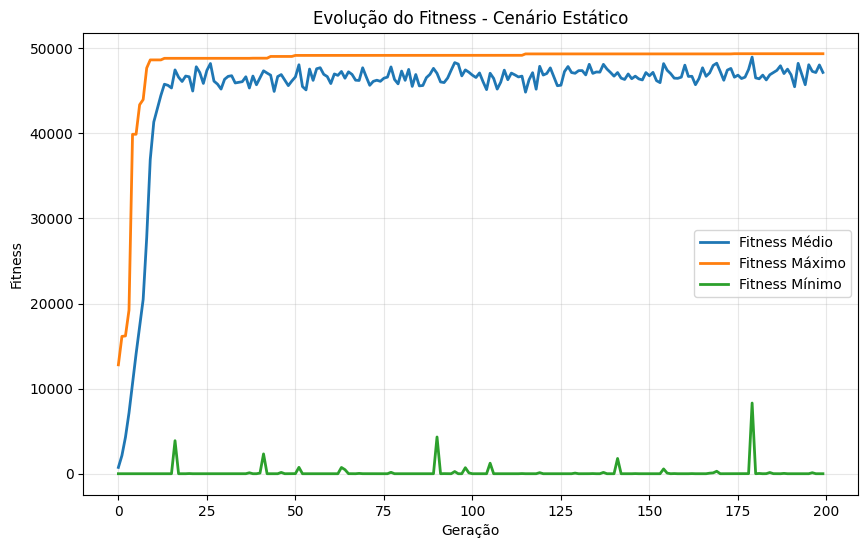

Gráfico salvo como 'fitness_evolution_static.png'


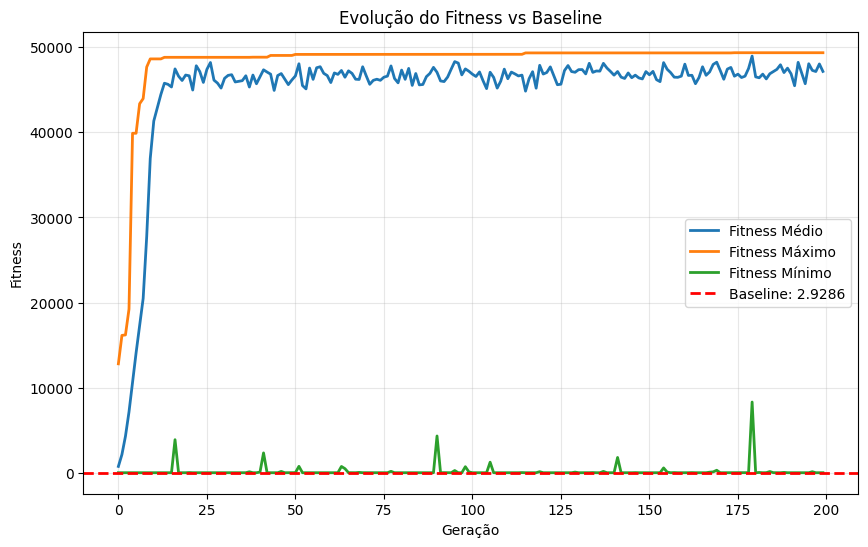

Gráfico com baseline salvo como 'fitness_with_baseline.png'


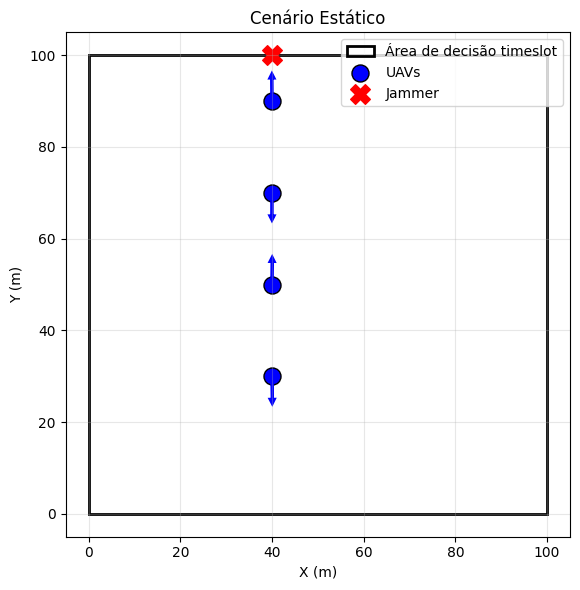

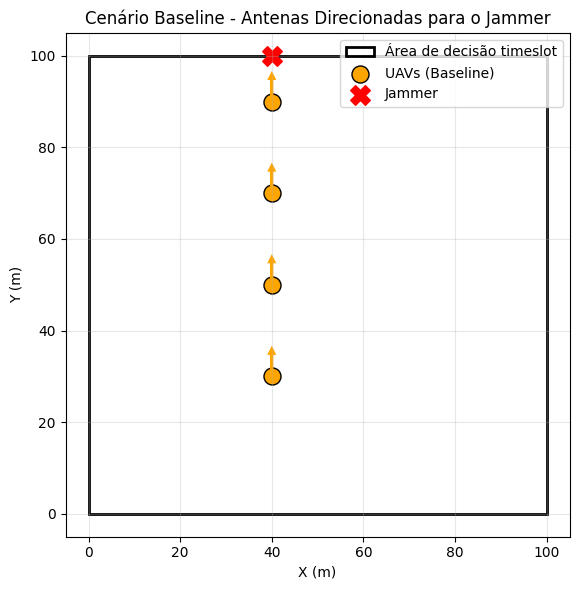

Cenário baseline plotado e salvo como 'baseline_scenario.png'

=== Simulação Completa ===
Arquivos gerados:
- fitness_values_static.txt: Evolução do fitness
- best_solution_static.txt: Melhor solução encontrada
- fitness_evolution_static.png: Gráfico da evolução


In [ ]:
import random
import numpy as np
import math
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
from functools import partial
import networkx as nx
from link_capacity import calcular_capacidade_link, interference_from_jammer
from antenna_null import realistic_antenna_gain

NUM_UAVS = 4
lambda_0 = 0.125
P_INTERFERENCE_DBM = 100
P_NOISE_DBM = -100
BANDWIDTH = 20e6
TRANSMIT_POWER_DBM = 20

# Definir os tipos de indivíduos e fitness
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Nova função para criar um indivíduo (agora apenas ângulos das antenas)
def create_individual(num_uavs):
    """
    Cria um indivíduo com apenas os ângulos das antenas dos UAVs.
    Cada UAV tem um ângulo entre 0 e 360 graus.
    """
    individual = []
    for uav in range(num_uavs):
        angle = random.uniform(0, 360)  # Ângulo da antena em graus
        individual.append(angle)
    
    return creator.Individual(individual)

def plot_static_scenario(best_solution, uav_positions, jammer_position, num_uavs, filename="static_scenario.png"):
    """
    Plota o cenário estático de forma simples.
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plotar área de decisão como quadrado preto
    square_size = 100
    square_x = 0  # Posição inicial do quadrado
    square_y = 0
    square = plt.Rectangle((square_x, square_y), square_size, square_size, 
                          fill=False, edgecolor='black', linewidth=2, linestyle='-',
                          label='Área de decisão timeslot')
    ax.add_patch(square)
    
    # Plotar UAVs como círculos
    for i, pos in enumerate(uav_positions):
        if i == 0:  # Só para aparecer uma vez na legenda
            ax.scatter(pos[0], pos[1], c='blue', s=150, marker='o', 
                      edgecolors='black', label='UAVs')
        else:
            ax.scatter(pos[0], pos[1], c='blue', s=150, marker='o', edgecolors='black')
        
        # Seta indicando direção da antena
        angle_rad = np.radians(best_solution[i])
        arrow_length = 5
        end_x = pos[0] + arrow_length * np.cos(angle_rad)
        end_y = pos[1] + arrow_length * np.sin(angle_rad)
        
        ax.arrow(pos[0], pos[1], end_x - pos[0], end_y - pos[1],
                head_width=1, head_length=1, fc='blue', ec='blue', linewidth=2)
    
    # Plotar jammer como cruz vermelha
    ax.scatter(jammer_position[0], jammer_position[1], c='red', s=200, 
              marker='X', label='Jammer')
    
    # Configurar plot
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Cenário Estático')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

def print_communication_values_static(individual, num_uavs, uav_positions, jammer_position):
    """
    Calcula e imprime os valores de comunicação para o cenário estático.
    """
    angles = individual  # Os ângulos das antenas são o próprio indivíduo
    alignments = [1.0] * num_uavs  # Alinhamento fixo
    
    comm_matrix, interference_matrix = calculate_communication_capacity(
        angles, alignments, uav_positions, jammer_position
    )
    
    # Avaliar grafo
    G = nx.DiGraph()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j and comm_matrix[i][j] > 0:
                G.add_edge(i, j, capacity=comm_matrix[i][j])

    # Encontrar links usados através dos caminhos mínimos
    links_usados = set()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j:
                try:
                    path = nx.shortest_path(G, source=i, target=j, weight=lambda u, v, d: 1/d['capacity'])
                    for u, v in zip(path[:-1], path[1:]):
                        links_usados.add((u, v))
                        links_usados.add((v, u))
                except:
                    pass
    
    # Cálculo usando apenas links usados
    capacidades_usadas = [comm_matrix[u][v] for u, v in links_usados if u < num_uavs and v < num_uavs]
    if capacidades_usadas:
        C_media_total = np.mean(capacidades_usadas)
        C_min_total = min(capacidades_usadas)
    else:
        C_media_total = 0
        C_min_total = 0
    
    # Calcular fitness
    alpha, beta = 1.0, 1.0
    fitness = (C_media_total ** alpha) * (C_min_total ** beta)
    
    return capacidades_usadas, interference_matrix, C_media_total, C_min_total, fitness

# Função para calcular a capacidade de comunicação (mantém-se igual)
def calculate_communication_capacity(antenna_angles, alignments, positions, jammer_position):
    communication_capacity = np.zeros((NUM_UAVS, NUM_UAVS))
    interference_matrix = np.full((NUM_UAVS, NUM_UAVS), P_INTERFERENCE_DBM)

    for i in range(NUM_UAVS):
        null_dir_i = antenna_angles[i]

        dx_jam = jammer_position[0] - positions[i][0]
        dy_jam = jammer_position[1] - positions[i][1]
        dir_jammer_to_uav = np.degrees(np.arctan2(dy_jam, dx_jam)) % 360

        G_jammer_i = realistic_antenna_gain(dir_jammer_to_uav, null_dir_i)

        dist_jammer_i = np.linalg.norm(positions[i] - jammer_position)
        P_interf_dBm_i = interference_from_jammer(P_INTERFERENCE_DBM, G_jammer_i, lambda_0, dist_jammer_i)

        interference_matrix[i, :] = P_interf_dBm_i

    for i in range(NUM_UAVS):
        for j in range(NUM_UAVS):
            if i != j:
                null_dir_i = antenna_angles[i]
                null_dir_j = antenna_angles[j]

                dx_ij = positions[j][0] - positions[i][0]
                dy_ij = positions[j][1] - positions[i][1]
                dir_tx_to_rx = np.degrees(np.arctan2(dy_ij, dx_ij)) % 360

                dx_ji = positions[i][0] - positions[j][0]
                dy_ji = positions[i][1] - positions[j][1]
                dir_rx_to_tx = np.degrees(np.arctan2(dy_ji, dx_ji)) % 360

                G_tx = realistic_antenna_gain(dir_tx_to_rx, null_dir_i)
                G_rx = realistic_antenna_gain(dir_rx_to_tx, null_dir_j)

                capacity = calcular_capacidade_link(
                    pos1=positions[i],
                    pos2=positions[j],
                    lambda_0=lambda_0,
                    P_tx_dBm=TRANSMIT_POWER_DBM,
                    G_tx_dB=G_tx,
                    G_rx_dB=G_rx,
                    P_interference_dBm=interference_matrix[i, j],
                    P_noise_dBm=P_NOISE_DBM,
                    bandwidth=BANDWIDTH
                )

                communication_capacity[i][j] = capacity

    return communication_capacity, interference_matrix

def evaluate_individual_static(individual, num_uavs, uav_positions, jammer_position):
    """
    Avalia um indivíduo no cenário estático.
    individual: lista com os ângulos das antenas [angle1, angle2, angle3, angle4]
    """
    angles = individual
    alignments = [1.0] * num_uavs
    
    # Calcular matriz de comunicação
    comm_matrix, _ = calculate_communication_capacity(angles, alignments, uav_positions, jammer_position)

    # Avaliar grafo
    G = nx.DiGraph()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j and comm_matrix[i][j] > 0:
                G.add_edge(i, j, capacity=comm_matrix[i][j])

    # Encontrar links usados através dos caminhos mínimos
    links_usados = set()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j:
                try:
                    path = nx.shortest_path(G, source=i, target=j, weight=lambda u, v, d: 1/d['capacity'])
                    for u, v in zip(path[:-1], path[1:]):
                        links_usados.add((u, v))
                        links_usados.add((v, u))
                except:
                    pass
    
    # Cálculo do fitness usando apenas links usados
    capacidades_usadas = [comm_matrix[u][v] for u, v in links_usados if u < num_uavs and v < num_uavs]
    if capacidades_usadas:
        C_media_total = np.mean(capacidades_usadas)
        C_min_total = min(capacidades_usadas)
    else:
        C_media_total = 0
        C_min_total = 0
    
    # Fitness
    alpha, beta = 1.0, 1.0
    fitness = (C_media_total ** alpha) * (C_min_total ** beta)
    
    return (fitness,)

def mutate_individual_static(individual, mutation_rate):
    """
    Mutação para o cenário estático - apenas muda os ângulos das antenas.
    """
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            individual[i] = random.uniform(0, 360)  # Novo ângulo aleatório
    
    return individual,

def custom_crossover_static(ind1, ind2):
    """
    Crossover para o cenário estático - troca ângulos entre indivíduos.
    """
    for i in range(len(ind1)):
        if random.random() < 0.5:
            ind1[i], ind2[i] = ind2[i], ind1[i]
    
    return ind1, ind2

# Configuração do DEAP para cenário estático
def setup_deap_static(num_uavs, crossover_rate, mutation_rate, uav_positions, jammer_position):
    toolbox = base.Toolbox()
    
    # Registrar funções
    toolbox.register("individual", create_individual, num_uavs=num_uavs)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate_individual_static, 
                     num_uavs=num_uavs, 
                     uav_positions=uav_positions, 
                     jammer_position=jammer_position)
    toolbox.register("mate", custom_crossover_static)
    toolbox.register("mutate", mutate_individual_static, mutation_rate=mutation_rate)
    toolbox.register("select", tools.selTournament, tournsize=3)
    
    return toolbox

def genetic_algorithm_static(num_uavs, population_size, generations, crossover_rate, mutation_rate, uav_positions, jammer_position):
    """
    Algoritmo genético para o cenário estático.
    """
    # Configurar o DEAP
    toolbox = setup_deap_static(
        num_uavs=num_uavs,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        uav_positions=uav_positions,
        jammer_position=jammer_position
    )
    
    # Criar população inicial
    population = toolbox.population(n=population_size)
    
    # Avaliar a população inicial
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
    
    # Configurar estatísticas
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    # Listas para armazenar os dados de cada geração
    gen_list = []
    avg_list = []
    std_list = []
    min_list = []
    max_list = []
    
    # Executar o algoritmo genético
    for gen in range(generations):
        algorithms.eaSimple(
            population, 
            toolbox, 
            cxpb=crossover_rate,
            mutpb=mutation_rate,
            ngen=1,
            stats=stats,
            verbose=False
        )
        
        # Coletar os dados da geração atual
        record = stats.compile(population)
        gen_list.append(gen)
        avg_list.append(record["avg"])
        std_list.append(record["std"])
        min_list.append(record["min"])
        max_list.append(record["max"])
        
        # Escrever os valores no arquivo
        write_fitness_values_static(gen, record["avg"], record["max"], record["min"], record["std"])
    
    # Retornar o melhor indivíduo
    best_individual = tools.selBest(population, k=1)[0]
    return best_individual

def write_fitness_values_static(gen, avg, max_val, min_val, std, filename="fitness_values_static.txt"):
    """
    Escreve os valores de fitness no arquivo para o cenário estático.
    """
    with open(filename, "a") as file:
        if gen == 0:
            file.write("=== Cenário Estático ===\n")
            file.write("gen\tavg\tmax\tmin\tstd\n")
        file.write(f"{gen}\t{avg:.4f}\t{max_val:.4f}\t{min_val:.4f}\t{std:.4f}\n")

def save_best_solution_static(best_solution, uav_positions, jammer_position, filename="best_solution_static.txt"):
    """
    Salva a melhor solução para o cenário estático.
    """
    with open(filename, "w") as file:
        file.write("=== Melhor Solução - Cenário Estático ===\n")
        file.write("Posições dos UAVs:\n")
        for i, pos in enumerate(uav_positions):
            file.write(f"UAV {i}: x={pos[0]:.2f}, y={pos[1]:.2f}\n")
        file.write(f"Posição do Jammer: x={jammer_position[0]:.2f}, y={jammer_position[1]:.2f}\n")
        file.write("Ângulos ótimos das antenas:\n")
        for i, angle in enumerate(best_solution):
            file.write(f"UAV {i}: {angle:.2f}°\n")

#MUDAR POSICAO
def calculate_baseline_metrics():
    """
    Calcula o fitness, capacidade média e mínima da baseline: todas as antenas direcionadas para o jammer.
    """
    # Posições padrão (mesmas da simulação)
    uav_positions = [
        np.array([40.0, 90.0]),   # UAV 0
        np.array([40.0, 70.0]),   # UAV 1
        np.array([40.0, 50.0]),   # UAV 2
        np.array([40.0, 30.0])    # UAV 3   # UAV 3
    ]
    jammer_position = np.array([40.0, 100.0])  # Mesma posição do jammer
    
    # Calcular ângulos direcionados para o jammer
    baseline_angles = []
    for pos in uav_positions:
        dx = jammer_position[0] - pos[0]
        dy = jammer_position[1] - pos[1]
        angle = np.degrees(np.arctan2(dy, dx)) % 360
        baseline_angles.append(angle)
    
    # Calcular métricas usando a mesma função
    capacidades_usadas, _, C_media_total, C_min_total, fitness = print_communication_values_static(
        baseline_angles, NUM_UAVS, uav_positions, jammer_position
    )
    
    return fitness, C_media_total, C_min_total, len(capacidades_usadas)

# Função principal para o cenário estático
def simulate_static_scenario(num_uavs=4, population_size=50, generations=50, crossover_rate=0.8, mutation_rate=0.15, uav_positions=None, jammer_position=None):
    """
    Simula o cenário estático com posições fixas e otimização apenas dos ângulos das antenas.
    """
    # Posições padrão se não fornecidas
    if uav_positions is None:
        uav_positions = [
            np.array([40.0, 90.0]),   # UAV 0
            np.array([40.0, 70.0]),   # UAV 1
            np.array([40.0, 50.0]),   # UAV 2
            np.array([40.0, 30.0])    # UAV 3   # UAV 3
        ]
    
    if jammer_position is None:
        jammer_position = np.array([40.0, 5.0])  # Jammer no centro
    
    print("=== Cenário Estático ===")
    print("Posições dos UAVs:")
    for i, pos in enumerate(uav_positions):
        print(f"  UAV {i}: x={pos[0]:.2f}, y={pos[1]:.2f}")
    print(f"Posição do Jammer: x={jammer_position[0]:.2f}, y={jammer_position[1]:.2f}")
    print()
    
    # Executar o algoritmo genético
    best_solution = genetic_algorithm_static(
        num_uavs=num_uavs,
        population_size=population_size,
        generations=generations,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        uav_positions=uav_positions,
        jammer_position=jammer_position
    )
    
    # Calcular e imprimir os resultados da melhor solução
    capacidades_usadas, interference_matrix, C_media_total, C_min_total, fitness = print_communication_values_static(
        best_solution, num_uavs, uav_positions, jammer_position
    )
    
    # Salvar a melhor solução
    save_best_solution_static(best_solution, uav_positions, jammer_position)
    
        # Imprimir resultados
    print("=== Resultados da Otimização ===")
    print("Ângulos ótimos das antenas:")
    for i, angle in enumerate(best_solution):
        print(f"  UAV {i}: {angle:.2f}°")
    print()
    print(f"Fitness final: {fitness:.4f}")
    print(f"Capacidade média dos links usados: {C_media_total:.2f} bps")
    print(f"Capacidade mínima dos links usados: {C_min_total:.2f} bps")
    print(f"Número de links usados: {len(capacidades_usadas)}")
    
    # ADICIONAR ESTAS LINHAS:
    # Calcular e imprimir métricas da baseline
    baseline_fitness, baseline_C_media, baseline_C_min, baseline_links = calculate_baseline_metrics()
    print("\n=== Baseline (Antenas → Jammer) ===")
    print(f"Fitness baseline: {baseline_fitness:.4f}")
    print(f"Capacidade média baseline: {baseline_C_media:.2f} bps")
    print(f"Capacidade mínima baseline: {baseline_C_min:.2f} bps")
    print(f"Número de links baseline: {baseline_links}")

    
    # Plotar gráfico de evolução do fitness (opcional)
    plot_fitness_evolution(filename="fitness_values_static.txt")
    
    plot_fitness_with_baseline(filename="fitness_values_static.txt")
    # ADICIONAR ESTA LINHA:
    # Plotar o cenário com as antenas otimizadas
    plot_static_scenario(best_solution, uav_positions, jammer_position, num_uavs)

    # Plotar o cenário baseline
    plot_baseline_scenario(uav_positions, jammer_position, num_uavs)
    
    return best_solution, uav_positions, jammer_position, capacidades_usadas, interference_matrix

def plot_fitness_evolution(filename="fitness_values_static.txt"):
    """
    Plota a evolução do fitness ao longo das gerações.
    """
    try:
        generations = []
        avg_fitness = []
        max_fitness = []
        min_fitness = []
        
        with open(filename, "r") as file:
            lines = file.readlines()
            for line in lines:
                if line.startswith("gen\t"):
                    continue  # Pular cabeçalho
                if "===" in line:
                    continue  # Pular linhas de separação
                
                parts = line.strip().split("\t")
                if len(parts) == 5:
                    generations.append(int(parts[0]))
                    avg_fitness.append(float(parts[1]))
                    max_fitness.append(float(parts[2]))
                    min_fitness.append(float(parts[3]))
        
        if generations:
            plt.figure(figsize=(10, 6))
            plt.plot(generations, avg_fitness, label='Fitness Médio', linewidth=2)
            plt.plot(generations, max_fitness, label='Fitness Máximo', linewidth=2)
            plt.plot(generations, min_fitness, label='Fitness Mínimo', linewidth=2)
            plt.xlabel('Geração')
            plt.ylabel('Fitness')
            plt.title('Evolução do Fitness - Cenário Estático')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig('fitness_evolution_static.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("Gráfico salvo como 'fitness_evolution_static.png'")
    
    except Exception as e:
        print(f"Erro ao plotar gráfico: {e}")

def plot_baseline_scenario(uav_positions, jammer_position, num_uavs, filename="baseline_scenario.png"):
    """
    Plota o cenário estático com as antenas na configuração baseline (direcionadas para o jammer).
    """
    # Calcular ângulos da baseline (direcionados para o jammer)
    baseline_angles = []
    for pos in uav_positions:
        dx = jammer_position[0] - pos[0]
        dy = jammer_position[1] - pos[1]
        angle = np.degrees(np.arctan2(dy, dx)) % 360
        baseline_angles.append(angle)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plotar área de decisão como quadrado preto
    square_size = 100
    square_x = 0  # Posição inicial do quadrado
    square_y = 0
    square = plt.Rectangle((square_x, square_y), square_size, square_size, 
                          fill=False, edgecolor='black', linewidth=2, linestyle='-',
                          label='Área de decisão timeslot')
    ax.add_patch(square)
    
    # Plotar UAVs como círculos
    for i, pos in enumerate(uav_positions):
        if i == 0:  # Só para aparecer uma vez na legenda
            ax.scatter(pos[0], pos[1], c='orange', s=150, marker='o', 
                      edgecolors='black', label='UAVs (Baseline)')
        else:
            ax.scatter(pos[0], pos[1], c='orange', s=150, marker='o', edgecolors='black')
        
        # Seta indicando direção da antena (baseline)
        angle_rad = np.radians(baseline_angles[i])
        arrow_length = 5
        end_x = pos[0] + arrow_length * np.cos(angle_rad)
        end_y = pos[1] + arrow_length * np.sin(angle_rad)
        
        ax.arrow(pos[0], pos[1], end_x - pos[0], end_y - pos[1],
                head_width=1, head_length=1, fc='orange', ec='orange', linewidth=2)
    
    # Plotar jammer como cruz vermelha
    ax.scatter(jammer_position[0], jammer_position[1], c='red', s=200, 
              marker='X', label='Jammer')
    
    # Configurar plot
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Cenário Baseline - Antenas Direcionadas para o Jammer')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f"Cenário baseline plotado e salvo como '{filename}'")

def plot_fitness_with_baseline(filename="fitness_values_static.txt"):
    """
    Plota a evolução do fitness ao longo das gerações COM a linha da baseline.
    """
    try:
        generations = []
        avg_fitness = []
        max_fitness = []
        min_fitness = []
        
        with open(filename, "r") as file:
            lines = file.readlines()
            for line in lines:
                if line.startswith("gen\t"):
                    continue  # Pular cabeçalho
                if "===" in line:
                    continue  # Pular linhas de separação
                
                parts = line.strip().split("\t")
                if len(parts) == 5:
                    generations.append(int(parts[0]))
                    avg_fitness.append(float(parts[1]))
                    max_fitness.append(float(parts[2]))
                    min_fitness.append(float(parts[3]))
        
        if generations:
            # Calcular fitness da baseline
            baseline_fitness, _, _, _ = calculate_baseline_metrics()
            
            plt.figure(figsize=(10, 6))
            plt.plot(generations, avg_fitness, label='Fitness Médio', linewidth=2)
            plt.plot(generations, max_fitness, label='Fitness Máximo', linewidth=2)
            plt.plot(generations, min_fitness, label='Fitness Mínimo', linewidth=2)
            
            # Adicionar linha horizontal da baseline
            plt.axhline(y=baseline_fitness, color='red', linestyle='--', linewidth=2, 
                       label=f'Baseline: {baseline_fitness:.4f}')
            
            plt.xlabel('Geração')
            plt.ylabel('Fitness')
            plt.title('Evolução do Fitness vs Baseline')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig('fitness_with_baseline.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("Gráfico com baseline salvo como 'fitness_with_baseline.png'")
    
    except Exception as e:
        print(f"Erro ao plotar gráfico: {e}")

# Exemplo de uso
if __name__ == "__main__":
    # Limpar arquivos anteriores
    open("fitness_values_static.txt", "w").close()
    
    # Definir posições específicas (você pode modificar estas)
    uav_positions = [
        np.array([40.0, 90.0]),   # UAV 0
        np.array([40.0, 70.0]),   # UAV 1
        np.array([40.0, 50.0]),   # UAV 2
        np.array([40.0, 30.0])    # UAV 3
    ]
    
    jammer_position = np.array([40.0, 100.0])  # Jammer no centro
    
    # Executar simulação
    best_solution, uav_pos, jammer_pos, capacidades, interference = simulate_static_scenario(
        num_uavs=4,
        population_size=200,
        generations=200,
        crossover_rate=0.8,
        mutation_rate=0.15,
        uav_positions=uav_positions,
        jammer_position=jammer_position
    )
    
    print("\n=== Simulação Completa ===")
    print("Arquivos gerados:")
    print("- fitness_values_static.txt: Evolução do fitness")
    print("- best_solution_static.txt: Melhor solução encontrada")
    print("- fitness_evolution_static.png: Gráfico da evolução")



# cenario A com imagens

=== Cenário Estático ===
Posições dos UAVs:
  UAV 0: x=20.00, y=80.00
  UAV 1: x=20.00, y=20.00
  UAV 2: x=80.00, y=80.00
  UAV 3: x=80.00, y=20.00
Posição do Jammer: x=50.00, y=100.00

=== Resultados da Otimização ===
Ângulos ótimos das antenas:
  UAV 0: 63.03°
  UAV 1: 31.73°
  UAV 2: 145.08°
  UAV 3: 322.80°

Fitness final: 3528.7772
Capacidade média dos links usados: 1832.67 bps
Capacidade mínima dos links usados: 1.93 bps
Número de links usados: 6

=== Baseline (Antenas → Jammer) ===
Fitness baseline: 384.4462
Capacidade média baseline: 69.86 bps
Capacidade mínima baseline: 5.50 bps
Número de links baseline: 6


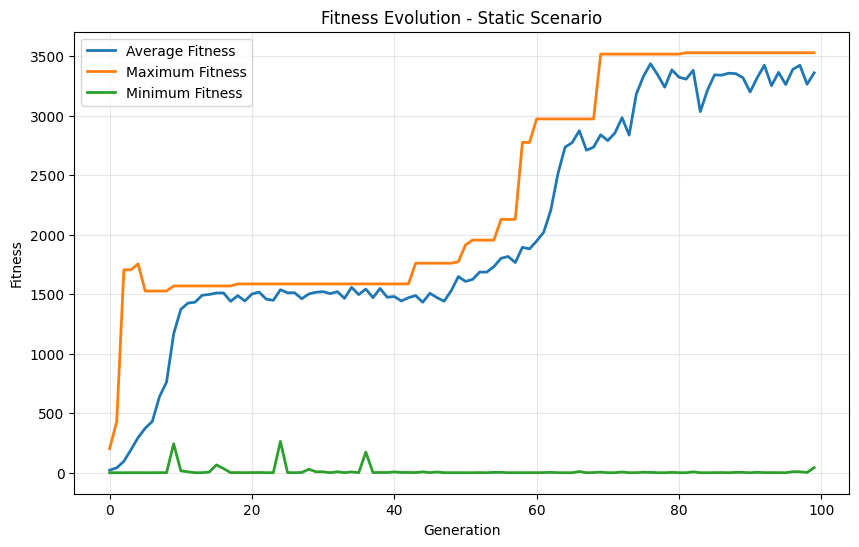

Gráfico salvo como 'fitness_evolution_static.png'


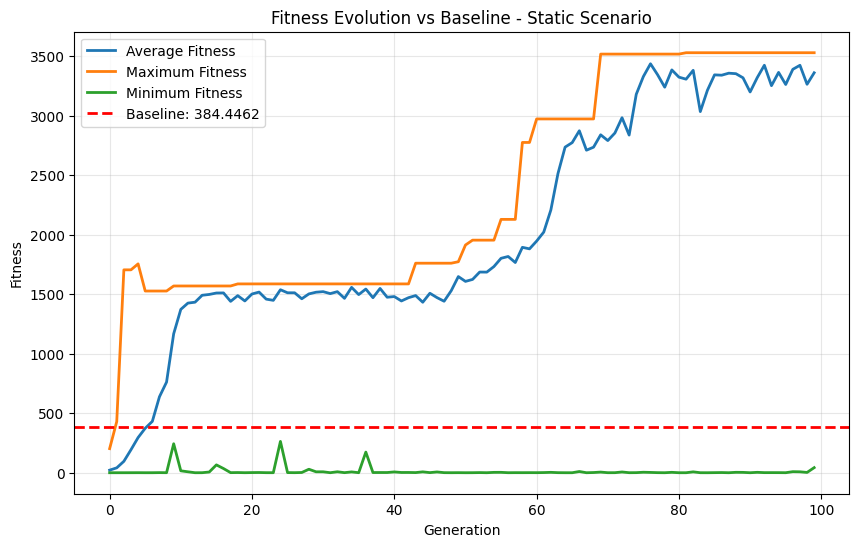

Gráfico com baseline salvo como 'fitness_with_baseline.png'


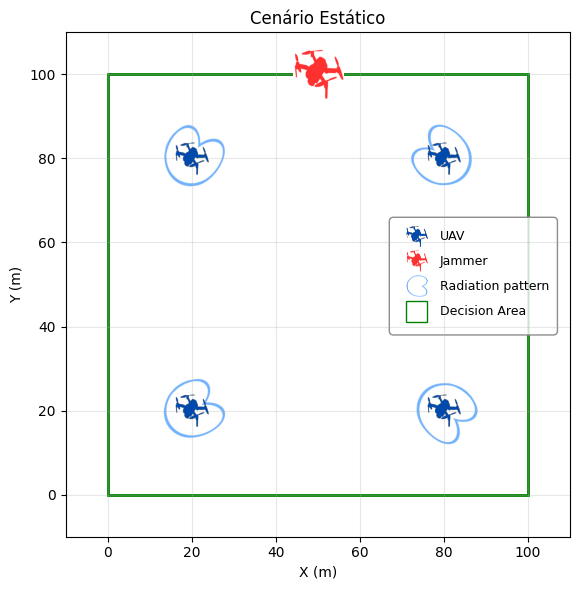

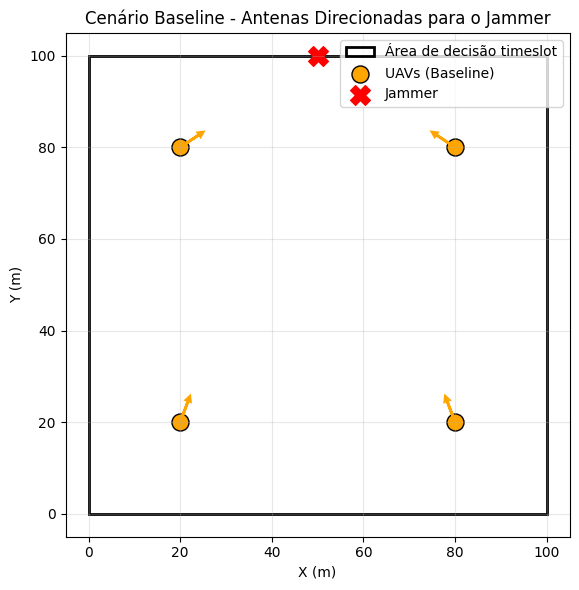

Cenário baseline plotado e salvo como 'baseline_scenario.png'

=== Simulação Completa ===
Arquivos gerados:
- fitness_values_static.txt: Evolução do fitness
- best_solution_static.txt: Melhor solução encontrada
- fitness_evolution_static.png: Gráfico da evolução


In [116]:
import random
import numpy as np
import math
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt
from functools import partial
import networkx as nx
from link_capacity import calcular_capacidade_link, interference_from_jammer
from antenna_null import realistic_antenna_gain
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from PIL import Image

NUM_UAVS = 4
lambda_0 = 0.125
P_INTERFERENCE_DBM = 100
P_NOISE_DBM = -100
BANDWIDTH = 20e6
TRANSMIT_POWER_DBM = 20

# Definir os tipos de indivíduos e fitness
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Nova função para criar um indivíduo (agora apenas ângulos das antenas)
def create_individual(num_uavs):
    """
    Cria um indivíduo com apenas os ângulos das antenas dos UAVs.
    Cada UAV tem um ângulo entre 0 e 360 graus.
    """
    individual = []
    for uav in range(num_uavs):
        angle = random.uniform(0, 360)  # Ângulo da antena em graus
        individual.append(angle)
    
    return creator.Individual(individual)


import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.transforms import Affine2D
from matplotlib.patches import Rectangle

def plot_static_scenario(best_solution, uav_positions, jammer_position,
                         uav_size=6, jammer_size=6, filename="static_scenario.png"):
    fig, ax = plt.subplots(figsize=(10, 6))

    square_size = 100
    ax.add_patch(Rectangle((0, 0), square_size, square_size,
                           fill=False, edgecolor='green', linewidth=2, linestyle='-',
                           label='Área de decisão timeslot'))

    # Carregar imagens
    uav_img = mpimg.imread("uav.png")
    jammer_img = mpimg.imread("jammer.png")
    radiation_img = mpimg.imread("padrao.png")  # tua imagem do padrão

    # Desenhar UAVs com padrão de radiação
    for i, pos in enumerate(uav_positions):
        angle_deg = best_solution[i]

        pattern_size = 7  # Tamanho do padrão de radiação

        trans_data = Affine2D().rotate_deg_around(pos[0], pos[1], angle_deg) + ax.transData
        ax.imshow(radiation_img,
                  extent=(pos[0] - pattern_size, pos[0] + pattern_size,
                          pos[1] - pattern_size, pos[1] + pattern_size),
                  transform=trans_data,
                  alpha=0.6,
                  zorder=1)

        ax.imshow(uav_img,
                  extent=(pos[0] - uav_size, pos[0] + uav_size,
                          pos[1] - uav_size, pos[1] + uav_size),
                  zorder=2)

    ax.imshow(jammer_img,
              extent=(jammer_position[0] - jammer_size, jammer_position[0] + jammer_size,
                      jammer_position[1] - jammer_size, jammer_position[1] + jammer_size),
              zorder=3)

    ax.set_xlim(-10, 110)
    ax.set_ylim(-10, 110)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Cenário Estático')

    # --- Legenda personalizada ---
    legend_x = 68
    legend_y = 105
    legend_width = 38
    legend_height = 26  # aumentei altura para 4 linhas

    from matplotlib.patches import FancyBboxPatch

    # --- Legenda personalizada ---
    legend_x = 68
    legend_y = 105
    legend_shift_y = -40  # 🔹 valor para mover a legenda toda para cima/baixo
    legend_width = 38
    legend_height = 26  # aumentei altura para 4 linhas

    from matplotlib.patches import FancyBboxPatch

    # Caixa da legenda
    legend_box = FancyBboxPatch(
        (legend_x, legend_y + legend_shift_y - legend_height),  # posição Y ajustada
        legend_width, legend_height,
        boxstyle="round,pad=1",
        linewidth=1,
        edgecolor='grey',
        facecolor='white',
        alpha=0.9
    )
    ax.add_patch(legend_box)

    icon_size = 5
    icon_shift_x = 2
    text_shift_x = 3
    text_shift_y = -2

    # UAV
    ax.imshow(uav_img,
        extent=(legend_x + 1 + icon_shift_x, legend_x + 1 + icon_size + icon_shift_x,
                legend_y + legend_shift_y - 4 + text_shift_y,
                legend_y + legend_shift_y - 4 + icon_size + text_shift_y),
        zorder=10)
    ax.text(legend_x + 1 + icon_size + 2 + text_shift_x,
            legend_y + legend_shift_y - 4 + icon_size / 2 + text_shift_y,
            "UAV", fontsize=9, verticalalignment='center')

    # Jammer
    ax.imshow(jammer_img,
        extent=(legend_x + 1 + icon_shift_x, legend_x + 1 + icon_size + icon_shift_x,
                legend_y + legend_shift_y - 10 + text_shift_y,
                legend_y + legend_shift_y - 10 + icon_size + text_shift_y),
        zorder=10)
    ax.text(legend_x + 1 + icon_size + 2 + text_shift_x,
            legend_y + legend_shift_y - 10 + icon_size / 2 + text_shift_y,
            "Jammer", fontsize=9, verticalalignment='center')

    # Radiation pattern
    ax.imshow(radiation_img,
        extent=(legend_x + 1 + icon_shift_x, legend_x + 1 + icon_size + icon_shift_x,
                legend_y + legend_shift_y - 16 + text_shift_y,
                legend_y + legend_shift_y - 16 + icon_size + text_shift_y),
        alpha=0.6, zorder=10)
    ax.text(legend_x + 1 + icon_size + 2 + text_shift_x,
            legend_y + legend_shift_y - 16 + icon_size / 2 + text_shift_y,
            "Radiation pattern", fontsize=9, verticalalignment='center')

    # Decision area
    rect_size = 5
    ax.add_patch(Rectangle(
        (legend_x + 1 + icon_shift_x,
        legend_y + legend_shift_y - 22 + text_shift_y),
        rect_size, rect_size,
        fill=False, edgecolor='green', linewidth=1, linestyle='-', zorder=10))
    ax.text(legend_x + 1 + rect_size + 2 + text_shift_x,
            legend_y + legend_shift_y - 22 + rect_size / 2 + text_shift_y,
            "Decision Area", fontsize=9, verticalalignment='center')


    plt.tight_layout()
    plt.savefig(filename)
    plt.show()




def print_communication_values_static(individual, num_uavs, uav_positions, jammer_position):
    """
    Calcula e imprime os valores de comunicação para o cenário estático.
    """
    angles = individual  # Os ângulos das antenas são o próprio indivíduo
    alignments = [1.0] * num_uavs  # Alinhamento fixo
    
    comm_matrix, interference_matrix = calculate_communication_capacity(
        angles, alignments, uav_positions, jammer_position
    )
    
    # Avaliar grafo
    G = nx.DiGraph()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j and comm_matrix[i][j] > 0:
                G.add_edge(i, j, capacity=comm_matrix[i][j])

    # Encontrar links usados através dos caminhos mínimos
    links_usados = set()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j:
                try:
                    path = nx.shortest_path(G, source=i, target=j, weight=lambda u, v, d: 1/d['capacity'])
                    for u, v in zip(path[:-1], path[1:]):
                        links_usados.add((u, v))
                        links_usados.add((v, u))
                except:
                    pass
    
    # Cálculo usando apenas links usados
    capacidades_usadas = [comm_matrix[u][v] for u, v in links_usados if u < num_uavs and v < num_uavs]
    if capacidades_usadas:
        C_media_total = np.mean(capacidades_usadas)
        C_min_total = min(capacidades_usadas)
    else:
        C_media_total = 0
        C_min_total = 0
    
    # Calcular fitness
    alpha, beta = 1.0, 1.0
    fitness = (C_media_total ** alpha) * (C_min_total ** beta)
    
    return capacidades_usadas, interference_matrix, C_media_total, C_min_total, fitness

# Função para calcular a capacidade de comunicação (mantém-se igual)
def calculate_communication_capacity(antenna_angles, alignments, positions, jammer_position):
    communication_capacity = np.zeros((NUM_UAVS, NUM_UAVS))
    interference_matrix = np.full((NUM_UAVS, NUM_UAVS), P_INTERFERENCE_DBM)

    for i in range(NUM_UAVS):
        null_dir_i = antenna_angles[i]

        dx_jam = jammer_position[0] - positions[i][0]
        dy_jam = jammer_position[1] - positions[i][1]
        dir_jammer_to_uav = np.degrees(np.arctan2(dy_jam, dx_jam)) % 360

        G_jammer_i = realistic_antenna_gain(dir_jammer_to_uav, null_dir_i)

        dist_jammer_i = np.linalg.norm(positions[i] - jammer_position)
        P_interf_dBm_i = interference_from_jammer(P_INTERFERENCE_DBM, G_jammer_i, lambda_0, dist_jammer_i)

        interference_matrix[i, :] = P_interf_dBm_i

    for i in range(NUM_UAVS):
        for j in range(NUM_UAVS):
            if i != j:
                null_dir_i = antenna_angles[i]
                null_dir_j = antenna_angles[j]

                dx_ij = positions[j][0] - positions[i][0]
                dy_ij = positions[j][1] - positions[i][1]
                dir_tx_to_rx = np.degrees(np.arctan2(dy_ij, dx_ij)) % 360

                dx_ji = positions[i][0] - positions[j][0]
                dy_ji = positions[i][1] - positions[j][1]
                dir_rx_to_tx = np.degrees(np.arctan2(dy_ji, dx_ji)) % 360

                G_tx = realistic_antenna_gain(dir_tx_to_rx, null_dir_i)
                G_rx = realistic_antenna_gain(dir_rx_to_tx, null_dir_j)

                capacity = calcular_capacidade_link(
                    pos1=positions[i],
                    pos2=positions[j],
                    lambda_0=lambda_0,
                    P_tx_dBm=TRANSMIT_POWER_DBM,
                    G_tx_dB=G_tx,
                    G_rx_dB=G_rx,
                    P_interference_dBm=interference_matrix[i, j],
                    P_noise_dBm=P_NOISE_DBM,
                    bandwidth=BANDWIDTH
                )

                communication_capacity[i][j] = capacity

    return communication_capacity, interference_matrix

def evaluate_individual_static(individual, num_uavs, uav_positions, jammer_position):
    """
    Avalia um indivíduo no cenário estático.
    individual: lista com os ângulos das antenas [angle1, angle2, angle3, angle4]
    """
    angles = individual
    alignments = [1.0] * num_uavs
    
    # Calcular matriz de comunicação
    comm_matrix, _ = calculate_communication_capacity(angles, alignments, uav_positions, jammer_position)

    # Avaliar grafo
    G = nx.DiGraph()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j and comm_matrix[i][j] > 0:
                G.add_edge(i, j, capacity=comm_matrix[i][j])

    # Encontrar links usados através dos caminhos mínimos
    links_usados = set()
    for i in range(num_uavs):
        for j in range(num_uavs):
            if i != j:
                try:
                    path = nx.shortest_path(G, source=i, target=j, weight=lambda u, v, d: 1/d['capacity'])
                    for u, v in zip(path[:-1], path[1:]):
                        links_usados.add((u, v))
                        links_usados.add((v, u))
                except:
                    pass
    
    # Cálculo do fitness usando apenas links usados
    capacidades_usadas = [comm_matrix[u][v] for u, v in links_usados if u < num_uavs and v < num_uavs]
    if capacidades_usadas:
        C_media_total = np.mean(capacidades_usadas)
        C_min_total = min(capacidades_usadas)
    else:
        C_media_total = 0
        C_min_total = 0
    
    # Fitness
    alpha, beta = 1.0, 1.0
    fitness = (C_media_total ** alpha) * (C_min_total ** beta)
    
    return (fitness,)

def mutate_individual_static(individual, mutation_rate):
    """
    Mutação para o cenário estático - apenas muda os ângulos das antenas.
    """
    for i in range(len(individual)):
        if random.random() < mutation_rate:
            individual[i] = random.uniform(0, 360)  # Novo ângulo aleatório
    
    return individual,

def custom_crossover_static(ind1, ind2):
    """
    Crossover para o cenário estático - troca ângulos entre indivíduos.
    """
    for i in range(len(ind1)):
        if random.random() < 0.5:
            ind1[i], ind2[i] = ind2[i], ind1[i]
    
    return ind1, ind2

# Configuração do DEAP para cenário estático
def setup_deap_static(num_uavs, crossover_rate, mutation_rate, uav_positions, jammer_position):
    toolbox = base.Toolbox()
    
    # Registrar funções
    toolbox.register("individual", create_individual, num_uavs=num_uavs)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate_individual_static, 
                     num_uavs=num_uavs, 
                     uav_positions=uav_positions, 
                     jammer_position=jammer_position)
    toolbox.register("mate", custom_crossover_static)
    toolbox.register("mutate", mutate_individual_static, mutation_rate=mutation_rate)
    toolbox.register("select", tools.selTournament, tournsize=3)
    
    return toolbox

def genetic_algorithm_static(num_uavs, population_size, generations, crossover_rate, mutation_rate, uav_positions, jammer_position):
    """
    Algoritmo genético para o cenário estático.
    """
    # Configurar o DEAP
    toolbox = setup_deap_static(
        num_uavs=num_uavs,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        uav_positions=uav_positions,
        jammer_position=jammer_position
    )
    
    # Criar população inicial
    population = toolbox.population(n=population_size)
    
    # Avaliar a população inicial
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
    
    # Configurar estatísticas
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    # Listas para armazenar os dados de cada geração
    gen_list = []
    avg_list = []
    std_list = []
    min_list = []
    max_list = []
    
    # Executar o algoritmo genético
    for gen in range(generations):
        algorithms.eaSimple(
            population, 
            toolbox, 
            cxpb=crossover_rate,
            mutpb=mutation_rate,
            ngen=1,
            stats=stats,
            verbose=False
        )
        
        # Coletar os dados da geração atual
        record = stats.compile(population)
        gen_list.append(gen)
        avg_list.append(record["avg"])
        std_list.append(record["std"])
        min_list.append(record["min"])
        max_list.append(record["max"])
        
        # Escrever os valores no arquivo
        write_fitness_values_static(gen, record["avg"], record["max"], record["min"], record["std"])
    
    # Retornar o melhor indivíduo
    best_individual = tools.selBest(population, k=1)[0]
    return best_individual

def write_fitness_values_static(gen, avg, max_val, min_val, std, filename="fitness_values_static.txt"):
    """
    Escreve os valores de fitness no arquivo para o cenário estático.
    """
    with open(filename, "a") as file:
        if gen == 0:
            file.write("=== Cenário Estático ===\n")
            file.write("gen\tavg\tmax\tmin\tstd\n")
        file.write(f"{gen}\t{avg:.4f}\t{max_val:.4f}\t{min_val:.4f}\t{std:.4f}\n")

def save_best_solution_static(best_solution, uav_positions, jammer_position, filename="best_solution_static.txt"):
    """
    Salva a melhor solução para o cenário estático.
    """
    with open(filename, "w") as file:
        file.write("=== Melhor Solução - Cenário Estático ===\n")
        file.write("Posições dos UAVs:\n")
        for i, pos in enumerate(uav_positions):
            file.write(f"UAV {i}: x={pos[0]:.2f}, y={pos[1]:.2f}\n")
        file.write(f"Posição do Jammer: x={jammer_position[0]:.2f}, y={jammer_position[1]:.2f}\n")
        file.write("Ângulos ótimos das antenas:\n")
        for i, angle in enumerate(best_solution):
            file.write(f"UAV {i}: {angle:.2f}°\n")

#MUDAR POSICAO
def calculate_baseline_metrics():
    """
    Calcula o fitness, capacidade média e mínima da baseline: todas as antenas direcionadas para o jammer.
    """
    # Posições padrão (mesmas da simulação)
    uav_positions = [
        np.array([20,80]),   # UAV 0
        np.array([20,20]),   # UAV 1
        np.array([80,80]),   # UAV 2
        np.array([80,20])    # UAV 3
    ]
    jammer_position = np.array([40.0, 100.0])  # Mesma posição do jammer
    
    # Calcular ângulos direcionados para o jammer
    baseline_angles = []
    for pos in uav_positions:
        dx = jammer_position[0] - pos[0]
        dy = jammer_position[1] - pos[1]
        angle = np.degrees(np.arctan2(dy, dx)) % 360
        baseline_angles.append(angle)
    
    # Calcular métricas usando a mesma função
    capacidades_usadas, _, C_media_total, C_min_total, fitness = print_communication_values_static(
        baseline_angles, NUM_UAVS, uav_positions, jammer_position
    )
    
    return fitness, C_media_total, C_min_total, len(capacidades_usadas)

# Função principal para o cenário estático
def simulate_static_scenario(num_uavs=4, population_size=50, generations=50, crossover_rate=0.8, mutation_rate=0.15, uav_positions=None, jammer_position=None):
    """
    Simula o cenário estático com posições fixas e otimização apenas dos ângulos das antenas.
    """
    # Posições padrão se não fornecidas
    if uav_positions is None:
        uav_positions = [
            np.array([40.0, 40.0]),   # UAV 0
            np.array([60.0, 60.0]),   # UAV 1
            np.array([40.0, 60.0]),   # UAV 2
            np.array([60.0, 40.0])    # UAV 3
        ]
    
    if jammer_position is None:
        jammer_position = np.array([40.0, 5.0])  # Jammer no centro
    
    print("=== Cenário Estático ===")
    print("Posições dos UAVs:")
    for i, pos in enumerate(uav_positions):
        print(f"  UAV {i}: x={pos[0]:.2f}, y={pos[1]:.2f}")
    print(f"Posição do Jammer: x={jammer_position[0]:.2f}, y={jammer_position[1]:.2f}")
    print()
    
    # Executar o algoritmo genético
    best_solution = genetic_algorithm_static(
        num_uavs=num_uavs,
        population_size=population_size,
        generations=generations,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        uav_positions=uav_positions,
        jammer_position=jammer_position
    )
    
    # Calcular e imprimir os resultados da melhor solução
    capacidades_usadas, interference_matrix, C_media_total, C_min_total, fitness = print_communication_values_static(
        best_solution, num_uavs, uav_positions, jammer_position
    )
    
    # Salvar a melhor solução
    save_best_solution_static(best_solution, uav_positions, jammer_position)
    
        # Imprimir resultados
    print("=== Resultados da Otimização ===")
    print("Ângulos ótimos das antenas:")
    for i, angle in enumerate(best_solution):
        print(f"  UAV {i}: {angle:.2f}°")
    print()
    print(f"Fitness final: {fitness:.4f}")
    print(f"Capacidade média dos links usados: {C_media_total:.2f} bps")
    print(f"Capacidade mínima dos links usados: {C_min_total:.2f} bps")
    print(f"Número de links usados: {len(capacidades_usadas)}")
    
    # ADICIONAR ESTAS LINHAS:
    # Calcular e imprimir métricas da baseline
    baseline_fitness, baseline_C_media, baseline_C_min, baseline_links = calculate_baseline_metrics()
    print("\n=== Baseline (Antenas → Jammer) ===")
    print(f"Fitness baseline: {baseline_fitness:.4f}")
    print(f"Capacidade média baseline: {baseline_C_media:.2f} bps")
    print(f"Capacidade mínima baseline: {baseline_C_min:.2f} bps")
    print(f"Número de links baseline: {baseline_links}")

    
    # Plotar gráfico de evolução do fitness (opcional)
    plot_fitness_evolution(filename="fitness_values_static.txt")
    
    plot_fitness_with_baseline(filename="fitness_values_static.txt")
    # ADICIONAR ESTA LINHA:
    # Plotar o cenário com as antenas otimizadas
    plot_static_scenario(best_solution, uav_positions, jammer_position, num_uavs)

    # Plotar o cenário baseline
    plot_baseline_scenario(uav_positions, jammer_position, num_uavs)

    
    
    return best_solution, uav_positions, jammer_position, capacidades_usadas, interference_matrix

def plot_fitness_evolution(filename="fitness_values_static.txt"):
    """
    Plota a evolução do fitness ao longo das gerações.
    """
    try:
        generations = []
        avg_fitness = []
        max_fitness = []
        min_fitness = []
        
        with open(filename, "r") as file:
            lines = file.readlines()
            for line in lines:
                if line.startswith("gen\t"):
                    continue  # Pular cabeçalho
                if "===" in line:
                    continue  # Pular linhas de separação
                
                parts = line.strip().split("\t")
                if len(parts) == 5:
                    generations.append(int(parts[0]))
                    avg_fitness.append(float(parts[1]))
                    max_fitness.append(float(parts[2]))
                    min_fitness.append(float(parts[3]))
        
        if generations:
            plt.figure(figsize=(10, 6))
            plt.plot(generations, avg_fitness, label='Average Fitness', linewidth=2)
            plt.plot(generations, max_fitness, label='Maximum Fitness', linewidth=2)
            plt.plot(generations, min_fitness, label='Minimum Fitness', linewidth=2)
            plt.xlabel('Generation')
            plt.ylabel('Fitness')
            plt.title('Fitness Evolution - Static Scenario')

            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig('fitness_evolution_static.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("Gráfico salvo como 'fitness_evolution_static.png'")
    
    except Exception as e:
        print(f"Erro ao plotar gráfico: {e}")

def plot_baseline_scenario(uav_positions, jammer_position, num_uavs, filename="baseline_scenario.png"):
    """
    Plota o cenário estático com as antenas na configuração baseline (direcionadas para o jammer).
    """
    # Calcular ângulos da baseline (direcionados para o jammer)
    baseline_angles = []
    for pos in uav_positions:
        dx = jammer_position[0] - pos[0]
        dy = jammer_position[1] - pos[1]
        angle = np.degrees(np.arctan2(dy, dx)) % 360
        baseline_angles.append(angle)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plotar área de decisão como quadrado preto
    square_size = 100
    square_x = 0  # Posição inicial do quadrado
    square_y = 0
    square = plt.Rectangle((square_x, square_y), square_size, square_size, 
                          fill=False, edgecolor='black', linewidth=2, linestyle='-',
                          label='Área de decisão timeslot')
    ax.add_patch(square)
    
    # Plotar UAVs como círculos
    for i, pos in enumerate(uav_positions):
        if i == 0:  # Só para aparecer uma vez na legenda
            ax.scatter(pos[0], pos[1], c='orange', s=150, marker='o', 
                      edgecolors='black', label='UAVs (Baseline)')
        else:
            ax.scatter(pos[0], pos[1], c='orange', s=150, marker='o', edgecolors='black')
        
        # Seta indicando direção da antena (baseline)
        angle_rad = np.radians(baseline_angles[i])
        arrow_length = 5
        end_x = pos[0] + arrow_length * np.cos(angle_rad)
        end_y = pos[1] + arrow_length * np.sin(angle_rad)
        
        ax.arrow(pos[0], pos[1], end_x - pos[0], end_y - pos[1],
                head_width=1, head_length=1, fc='orange', ec='orange', linewidth=2)
    
    # Plotar jammer como cruz vermelha
    ax.scatter(jammer_position[0], jammer_position[1], c='red', s=200, 
              marker='X', label='Jammer')
    
    # Configurar plot
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Cenário Baseline - Antenas Direcionadas para o Jammer')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    print(f"Cenário baseline plotado e salvo como '{filename}'")

def plot_fitness_with_baseline(filename="fitness_values_static.txt"):
    """
    Plota a evolução do fitness ao longo das gerações COM a linha da baseline.
    """
    try:
        generations = []
        avg_fitness = []
        max_fitness = []
        min_fitness = []
        
        with open(filename, "r") as file:
            lines = file.readlines()
            for line in lines:
                if line.startswith("gen\t"):
                    continue  # Pular cabeçalho
                if "===" in line:
                    continue  # Pular linhas de separação
                
                parts = line.strip().split("\t")
                if len(parts) == 5:
                    generations.append(int(parts[0]))
                    avg_fitness.append(float(parts[1]))
                    max_fitness.append(float(parts[2]))
                    min_fitness.append(float(parts[3]))
        
        if generations:
            # Calcular fitness da baseline
            baseline_fitness, _, _, _ = calculate_baseline_metrics()
            
            plt.figure(figsize=(10, 6))
            plt.plot(generations, avg_fitness, label='Average Fitness', linewidth=2)
            plt.plot(generations, max_fitness, label='Maximum Fitness', linewidth=2)
            plt.plot(generations, min_fitness, label='Minimum Fitness', linewidth=2)
            
            # Adicionar linha horizontal da baseline
            plt.axhline(y=baseline_fitness, color='red', linestyle='--', linewidth=2, 
                       label=f'Baseline: {baseline_fitness:.4f}')
            
            plt.xlabel('Generation')
            plt.ylabel('Fitness')
            plt.title('Fitness Evolution vs Baseline - Static Scenario')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.savefig('fitness_with_baseline.png', dpi=300, bbox_inches='tight')
            plt.show()
            print("Gráfico com baseline salvo como 'fitness_with_baseline.png'")
    
    except Exception as e:
        print(f"Erro ao plotar gráfico: {e}")

# Exemplo de uso
if __name__ == "__main__":
    # Limpar arquivos anteriores
    open("fitness_values_static.txt", "w").close()
    
    # Definir posições específicas (você pode modificar estas)
    uav_positions = [
        np.array([20,80]),   # UAV 0
        np.array([20,20]),   # UAV 1
        np.array([80,80]),   # UAV 2
        np.array([80,20])    # UAV 3
    ]
    
    jammer_position = np.array([50.0, 100.0])  # Jammer no centro
    
    # Executar simulação
    best_solution, uav_pos, jammer_pos, capacidades, interference = simulate_static_scenario(
        num_uavs=4,
        population_size=100,
        generations=100,
        crossover_rate=0.8,
        mutation_rate=0.15,
        uav_positions=uav_positions,
        jammer_position=jammer_position
    )
    
    print("\n=== Simulação Completa ===")
    print("Arquivos gerados:")
    print("- fitness_values_static.txt: Evolução do fitness")
    print("- best_solution_static.txt: Melhor solução encontrada")
    print("- fitness_evolution_static.png: Gráfico da evolução")

